In [1]:
import os

def get_headers(file_path):
    headers = set()
    if not os.path.exists(file_path):
        print(f"警告: 找不到文件 {file_path}")
        return headers
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('>'):
                header_id = line.strip().split()[0]
                headers.add(header_id)
    return headers

def main():
    # 1. 定义原始文件路径
    original_pos_file = './data_input/515_voltage.fasta'
    original_neg_file = './data_input/872_non_voltage.fasta'

    print("正在读取原始文件...")
    pos_ids = get_headers(original_pos_file)
    neg_ids = get_headers(original_neg_file)

    print(f"原始 VGICs (515) 数量: {len(pos_ids)}")
    print(f"原始 non-VGICs (872) 数量: {len(neg_ids)}")
    print("-" * 50)

    # 2. 定义需要统计的 CD-HIT 输出文件
    # 根据你的截图，文件名模式为 first_0.X.fasta
    thresholds = [0.4]

    print(f"{'阈值 (CD-HIT)':<15} | {'VGICs (来自515)':<15} | {'non-VGICs (来自872)':<15} | {'总计':<10}")
    print("-" * 65)

    target_file = "./data_input/input_sequence_cdhit_0.4_2023.fasta"
    
    if not os.path.exists(target_file):
        print(f"{target_file:<15} | 文件不存在")
        continue

    # 读取 CD-HIT 处理后的序列
    rep_ids = get_headers(target_file)

    # 计算交集（Intersection）
    # 看有多少代表序列在原始正样本集合中
    count_pos = len(rep_ids.intersection(pos_ids))
    # 看有多少代表序列在原始负样本集合中
    count_neg = len(rep_ids.intersection(neg_ids))
    
    total = len(rep_ids)

    # 打印结果
    print(f"{th:<15} | {count_pos:<15} | {count_neg:<15} | {total:<10}")

    # 简单的完整性检查
    if count_pos + count_neg != total:
        print(f"  警告: 阈值 {th} 中有 {total - (count_pos + count_neg)} 条序列无法归类到原始515或872中！")

if __name__ == "__main__":
    main()

正在读取原始文件...
原始 VGICs (515) 数量: 515
原始 non-VGICs (872) 数量: 872
--------------------------------------------------
阈值 (CD-HIT)     | VGICs (来自515)   | non-VGICs (来自872) | 总计        
-----------------------------------------------------------------
0.4             | 100             | 243             | 343       


In [24]:
import os
import random

def read_fasta(file_path):
    """读取FASTA文件，返回字典 {header_id: full_record}"""
    sequences = {}
    if not os.path.exists(file_path):
        return sequences
    
    with open(file_path, 'r', encoding='utf-8') as f:
        header = None
        seq_lines = []
        for line in f:
            if line.startswith('>'):
                if header:
                    sequences[header] = "".join(seq_lines)
                header = line.strip().split()[0]
                seq_lines = [line]
            else:
                seq_lines.append(line)
        if header:
            sequences[header] = "".join(seq_lines)
    return sequences

def save_fasta(data_dict, ids, output_path):
    with open(output_path, 'w', encoding='utf-8') as f:
        for seq_id in ids:
            f.write(data_dict[seq_id])

def main():
    # 配置
    SEEDS = [42, 2023, 1234, 567, 100]
    input_file = './data_input/input_sequence_cdhit_0.4_2023.fasta'
    pos_ref_file = './data_input/515_voltage.fasta'
    neg_ref_file = './data_input/872_non_voltage.fasta'
    
    TRAIN_RATIO = 0.8

    # 1. 加载数据
    all_data = read_fasta(input_file)
    pos_ids_all = set(read_fasta(pos_ref_file).keys())
    neg_ids_all = set(read_fasta(neg_ref_file).keys())

    # 2. 归类当前序列
    current_pos = [idx for idx in all_data if idx in pos_ids_all]
    current_neg = [idx for idx in all_data if idx in neg_ids_all]
    
    print(f"检测到总序列数: {len(all_data)}")
    print(f"正样本 (VGICs): {len(current_pos)}, 负样本 (non-VGICs): {len(current_neg)}")

    for seed in SEEDS:
        random.seed(seed)
        pos_list = current_pos[:]
        neg_list = current_neg[:]
        
        random.shuffle(pos_list)
        random.shuffle(neg_list)

        # 简化的分层采样函数：只返回训练和测试
        def split_list_82(lst):
            n = len(lst)
            tr_end = int(n * TRAIN_RATIO)
            return lst[:tr_end], lst[tr_end:]

        pos_tr, pos_te = split_list_82(pos_list)
        neg_tr, neg_te = split_list_82(neg_list)

        # 合并并打乱
        train_ids = pos_tr + neg_tr
        test_ids = pos_te + neg_te
        random.shuffle(train_ids)
        random.shuffle(test_ids)

        # 3. 创建目录并保存
        output_dir = f"split_seed_{seed}"
        os.makedirs(output_dir, exist_ok=True)
        
        save_fasta(all_data, train_ids, os.path.join(output_dir, 'train.fasta'))
        save_fasta(all_data, test_ids, os.path.join(output_dir, 'test.fasta'))
        
        print(f"Seed {seed}: 训练集={len(train_ids)}, 测试集={len(test_ids)} -> 已保存至 {output_dir}")

if __name__ == "__main__":
    main()

检测到总序列数: 343
正样本 (VGICs): 100, 负样本 (non-VGICs): 243
Seed 42: 训练集=274, 测试集=69 -> 已保存至 split_seed_42
Seed 2023: 训练集=274, 测试集=69 -> 已保存至 split_seed_2023
Seed 1234: 训练集=274, 测试集=69 -> 已保存至 split_seed_1234
Seed 567: 训练集=274, 测试集=69 -> 已保存至 split_seed_567
Seed 100: 训练集=274, 测试集=69 -> 已保存至 split_seed_100


In [52]:
import os
import random
from Bio import Align

def read_fasta(file_path):
    """读取FASTA文件，返回字典 {header_id: (full_record, pure_sequence)}"""
    sequences = {}
    if not os.path.exists(file_path):
        return sequences
    with open(file_path, 'r', encoding='utf-8') as f:
        header, seq_lines = None, []
        for line in f:
            if line.startswith('>'):
                if header:
                    sequences[header] = ("".join(seq_lines), "".join([l.strip() for l in seq_lines[1:]]))
                header = line.strip().split()[0]
                seq_lines = [line]
            else:
                seq_lines.append(line)
        if header:
            sequences[header] = ("".join(seq_lines), "".join([l.strip() for l in seq_lines[1:]]))
    return sequences

def get_aligner():
    """配置全局比对器"""
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1
    aligner.mismatch_score = 0
    aligner.open_gap_score = 0
    aligner.extend_gap_score = 0
    return aligner

def refine_split(test_ids, train_ids, all_data, aligner, threshold=0.6):
    """核心校验逻辑：检查测试集，将泄露序列归入训练集"""
    clean_test_ids = []
    leaked_to_train = []
    
    for idx, te_id in enumerate(test_ids):
        te_seq = all_data[te_id][1]
        is_leaked = False
        for tr_id in train_ids:
            tr_seq = all_data[tr_id][1]
            score = aligner.score(te_seq, tr_seq)
            identity = score / max(len(te_seq), len(tr_seq))
            if identity >= threshold:
                is_leaked = True
                break
        
        if is_leaked:
            leaked_to_train.append(te_id)
        else:
            clean_test_ids.append(te_id)
            
    return clean_test_ids, leaked_to_train

def save_fasta(data_dict, ids, output_path):
    with open(output_path, 'w', encoding='utf-8') as f:
        for seq_id in ids:
            f.write(data_dict[seq_id][0])

def main():
    SEEDS = [42, 2023, 1234, 567, 100]
    input_file = './data_input/input_sequence_cdhit_0.4_2023.fasta'
    pos_ref_file = './data_input/515_voltage.fasta'
    neg_ref_file = './data_input/872_non_voltage.fasta'
    TRAIN_RATIO = 0.8
    aligner = get_aligner()

    all_data = read_fasta(input_file)
    pos_ids_all = set(read_fasta(pos_ref_file).keys())
    neg_ids_all = set(read_fasta(neg_ref_file).keys())

    current_pos = [idx for idx in all_data if idx in pos_ids_all]
    current_neg = [idx for idx in all_data if idx in neg_ids_all]

    for seed in SEEDS:
        print(f"\n--- Processing Seed {seed} ---")
        random.seed(seed)
        pos_list, neg_list = current_pos[:], current_neg[:]
        random.shuffle(pos_list)
        random.shuffle(neg_list)

        # 1. 初始随机分割
        p_split = int(len(pos_list) * TRAIN_RATIO)
        n_split = int(len(neg_list) * TRAIN_RATIO)
        
        train_ids = pos_list[:p_split] + neg_list[:n_split]
        test_ids = pos_list[p_split:] + neg_list[n_split:]

        # 2. 第一轮校验
        print(f"第一轮校验中...")
        test_ids, leaked_1 = refine_split(test_ids, train_ids, all_data, aligner)
        train_ids.extend(leaked_1)
        print(f"  第一轮归类到训练集: {len(leaked_1)} 条")

        # 3. 第二轮校验 (确保第一轮新加入训练集的序列不会与剩下的测试序列冲突)
        if leaked_1:
            print(f"第二轮校验中...")
            test_ids, leaked_2 = refine_split(test_ids, train_ids, all_data, aligner)
            train_ids.extend(leaked_2)
            print(f"  第二轮归类到训练集: {len(leaked_2)} 条")
        else:
            print("第一轮无泄露，跳过第二轮。")

        # 4. 最终打乱训练集并保存
        random.shuffle(train_ids)
        output_dir = f"split2_seed_{seed}"
        os.makedirs(output_dir, exist_ok=True)
        
        save_fasta(all_data, train_ids, os.path.join(output_dir, 'train.fasta'))
        save_fasta(all_data, test_ids, os.path.join(output_dir, 'test.fasta'))
        
        print(f"完成! 最终统计: 训练集={len(train_ids)}, 测试集={len(test_ids)}")

if __name__ == "__main__":
    main()


--- Processing Seed 42 ---
第一轮校验中...
  第一轮归类到训练集: 0 条
第一轮无泄露，跳过第二轮。
完成! 最终统计: 训练集=274, 测试集=69

--- Processing Seed 2023 ---
第一轮校验中...
  第一轮归类到训练集: 2 条
第二轮校验中...
  第二轮归类到训练集: 0 条
完成! 最终统计: 训练集=276, 测试集=67

--- Processing Seed 1234 ---
第一轮校验中...
  第一轮归类到训练集: 1 条
第二轮校验中...
  第二轮归类到训练集: 0 条
完成! 最终统计: 训练集=275, 测试集=68

--- Processing Seed 567 ---
第一轮校验中...
  第一轮归类到训练集: 1 条
第二轮校验中...
  第二轮归类到训练集: 0 条
完成! 最终统计: 训练集=275, 测试集=68

--- Processing Seed 100 ---
第一轮校验中...
  第一轮归类到训练集: 1 条
第二轮校验中...
  第二轮归类到训练集: 0 条
完成! 最终统计: 训练集=275, 测试集=68


In [54]:
import os
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio import Align

def calculate_identity(seq1, seq2):
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1
    aligner.mismatch_score = 0
    aligner.open_gap_score = 0
    aligner.extend_gap_score = 0
    score = aligner.score(seq1, seq2)
    return score / max(len(seq1), len(seq2))

def get_seed_stats(seed, train_fasta, test_fasta):
    if not os.path.exists(train_fasta) or not os.path.exists(test_fasta):
        print(f"警告：找不到种子 {seed} 的文件路径: {os.path.dirname(train_fasta)}")
        return None

    train_recs = list(SeqIO.parse(train_fasta, "fasta"))
    test_recs = list(SeqIO.parse(test_fasta, "fasta"))
    
    if len(test_recs) == 0:
        print(f"警告：种子 {seed} 的测试集为空。")
        return None

    max_identities = []
    print(f"正在分析 Seed {seed} (N_test={len(test_recs)})...")

    for i, test_rec in enumerate(test_recs):
        current_max = 0
        test_seq = str(test_rec.seq)
        for train_rec in train_recs:
            iden = calculate_identity(test_seq, str(train_rec.seq))
            if iden > current_max:
                current_max = iden
        max_identities.append(current_max)
    
    max_ids = np.array(max_identities)
    
    return {
        'Seed': seed,
        'N(test)': len(max_ids),
        'Median': np.median(max_ids),
        '90th': np.quantile(max_ids, 0.90),
        '95th': np.quantile(max_ids, 0.95),
        '99th': np.quantile(max_ids, 0.99),
        'Max': np.max(max_ids),
        '% < 50%': (max_ids < 0.5).mean() * 100,
        '% ≥ 60%': (max_ids >= 0.6).mean() * 100
    }

def main():
    SEEDS = [42, 2023, 1234, 567, 100]
    results = []

    for seed in SEEDS:
        folder_path = f'split_seed_{seed}' 
        train_path = os.path.join(folder_path, 'train.fasta')
        test_path = os.path.join(folder_path, 'test.fasta')
        
        stat = get_seed_stats(seed, train_path, test_path)
        if stat:
            results.append(stat)

    if not results:
        print("\n错误：未在任何种子文件夹中找到有效数据。请检查文件路径设置。")
        return

    # 生成 DataFrame
    df = pd.DataFrame(results)

    # 只有当列存在时才进行格式化
    format_mapping = {
        'Median': '{:.3f}',
        '90th': '{:.3f}',
        '95th': '{:.3f}',
        '99th': '{:.3f}',
        'Max': '{:.3f}',
        '% < 50%': '{:.1f}%',
        '% ≥ 60%': '{:.1f}%'
    }
    
    for col, fmt in format_mapping.items():
        if col in df.columns:
            df[col] = df[col].apply(lambda x: fmt.format(x))

    print("\n" + "="*80)
    print("Supplementary Table: Homology Control Summary Across Multiple Seeds")
    print("="*80)
    print(df.to_string(index=False))
    
    df.to_csv("Multi_Seed_Quantile_Table.csv", index=False)
    print("\n结果已保存至 Multi_Seed_Quantile_Table.csv")

if __name__ == "__main__":
    main()

正在分析 Seed 42 (N_test=69)...
正在分析 Seed 2023 (N_test=67)...
正在分析 Seed 1234 (N_test=68)...
正在分析 Seed 567 (N_test=68)...
正在分析 Seed 100 (N_test=68)...

Supplementary Table: Homology Control Summary Across Multiple Seeds
 Seed  N(test) Median  90th  95th  99th   Max % < 50% % ≥ 60%
   42       69  0.401 0.475 0.515 0.544 0.579   92.8%    0.0%
 2023       67  0.420 0.479 0.525 0.598 0.600   92.5%    0.0%
 1234       68  0.409 0.464 0.481 0.537 0.566   97.1%    0.0%
  567       68  0.426 0.494 0.523 0.598 0.600   89.7%    0.0%
  100       68  0.404 0.461 0.468 0.570 0.579   97.1%    0.0%

结果已保存至 Multi_Seed_Quantile_Table.csv


Processing Seed 42 (Test: 69, Train: 274)...


100%|██████████| 69/69 [00:12<00:00,  5.35it/s]


Processing Seed 2023 (Test: 67, Train: 276)...


100%|██████████| 67/67 [00:13<00:00,  4.87it/s]


Processing Seed 1234 (Test: 68, Train: 275)...


...

Processing Seed 567 (Test: 68, Train: 275)...


100%|██████████| 68/68 [00:13<00:00,  4.87it/s]


Processing Seed 100 (Test: 68, Train: 275)...


100%|██████████| 68/68 [00:13<00:00,  4.98it/s]


绘图数据已保存至: Plot_Data_Identity_Histogram.csv


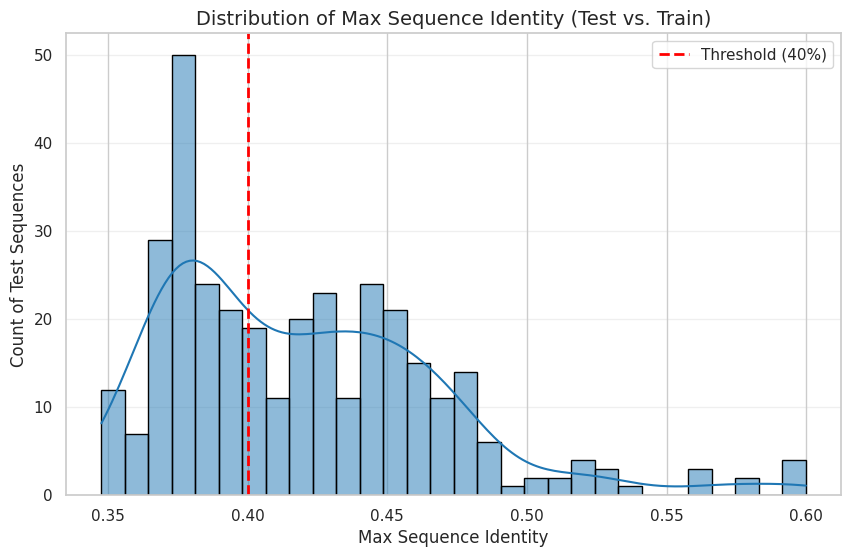

In [20]:
import os
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio import Align
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  

# 全局初始化 aligner，避免循环中重复创建，大幅提速
aligner = Align.PairwiseAligner()
aligner.mode = 'global'
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.open_gap_score = 0
aligner.extend_gap_score = 0

def calculate_identity_fast(seq1, seq2):
    # 简单的长度检查，避免比对差异过大的序列
    len1, len2 = len(seq1), len(seq2)
    min_len = min(len1, len2)
    if min_len == 0: return 0
    
    score = aligner.score(seq1, seq2)
    return score / max(len1, len2)

def process_seed(seed, train_fasta, test_fasta):
    if not os.path.exists(train_fasta) or not os.path.exists(test_fasta):
        print(f"File not found for seed {seed}")
        return None

    # 读取序列
    train_seqs = [str(r.seq) for r in SeqIO.parse(train_fasta, "fasta")]
    test_recs = list(SeqIO.parse(test_fasta, "fasta"))
    
    results = []
    
    print(f"Processing Seed {seed} (Test: {len(test_recs)}, Train: {len(train_seqs)})...")
    
    # 遍历测试集
    for test_rec in tqdm(test_recs):
        test_seq = str(test_rec.seq)
        current_max = 0
        
        for t_seq in train_seqs:
            # 简单剪枝：如果长度差异太大，直接跳过（可选优化）
            if abs(len(test_seq) - len(t_seq)) > 1000: 
                continue
                
            iden = calculate_identity_fast(test_seq, t_seq)
            if iden > current_max:
                current_max = iden
        
        results.append({
            'Seed': seed,
            'Sequence_ID': test_rec.id,
            'Max_Identity': current_max
        })
        
    return results

def main():
    # === 配置区域 ===
    SEEDS = [42, 2023, 1234, 567, 100] 
    folder_prefix = 'split_seed_'
    # ===============

    all_data = []

    for seed in SEEDS:
        folder_path = f'{folder_prefix}{seed}'
        train_path = os.path.join(folder_path, 'train.fasta')
        test_path = os.path.join(folder_path, 'test.fasta')
        
        seed_data = process_seed(seed, train_path, test_path)
        if seed_data:
            all_data.extend(seed_data)

    if not all_data:
        print("No data processed.")
        return

    # 1. 保存原始绘图数据
    df = pd.DataFrame(all_data)
    df.to_csv("Plot_Data_Identity_Histogram.csv", index=False)
    print("\n绘图数据已保存至: Plot_Data_Identity_Histogram.csv")

    # 2. 绘制直方图 (使用 Seaborn)
    plt.figure(figsize=(10, 6))

    sns.histplot(data=df, x='Max_Identity', bins=30, kde=True, color='#1f77b4', edgecolor='black')
    
    # 添加阈值线 (例如 40%)
    plt.axvline(x=0.4, color='red', linestyle='--', linewidth=2, label='Threshold (40%)')
    
    plt.title('Distribution of Max Sequence Identity (Test vs. Train)', fontsize=14)
    plt.xlabel('Max Sequence Identity', fontsize=12)
    plt.ylabel('Count of Test Sequences', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

if __name__ == "__main__":
    main()

=== 开始多线性同源性验证 ===
  正在计算 Seed 42 (N=69)...
  正在计算 Seed 2023 (N=67)...
  正在计算 Seed 1234 (N=68)...
  正在计算 Seed 567 (N=68)...
  正在计算 Seed 100 (N=68)...

[成功] 所有原始数据已保存至: Source_Data_ECDF_All_Seeds.csv
建议将此文件作为 'Source Data' 随论文提交。
正在绘图...


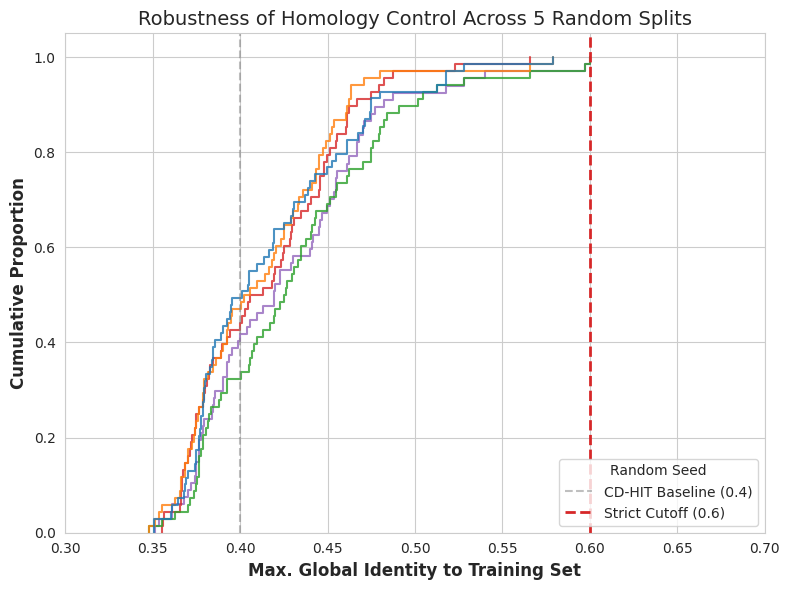

[成功] 图片已保存至: ECDF_All_Seeds_Robustness.png


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio import Align

# ================= 配置区域 =================
SEEDS = [42, 2023, 1234, 567, 100]
FOLDER_PREFIX = "split_seed_"
CSV_FILENAME = "Source_Data_ECDF_All_Seeds.csv"
PLOT_FILENAME = "ECDF_All_Seeds_Robustness.png"
# ===========================================

def get_aligner():
    """配置全局比对器"""
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 1
    aligner.mismatch_score = 0
    aligner.open_gap_score = 0
    aligner.extend_gap_score = 0
    return aligner

def calculate_max_identities(seed, train_path, test_path, aligner):
    """计算单个Seed下所有测试序列的最大相似度"""
    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print(f"警告: Seed {seed} 的文件未找到，跳过。")
        return []

    train_recs = list(SeqIO.parse(train_path, "fasta"))
    test_recs = list(SeqIO.parse(test_path, "fasta"))
    train_seqs = [str(r.seq) for r in train_recs]
    
    max_ids = []
    print(f"  正在计算 Seed {seed} (N={len(test_recs)})...")
    
    for i, rec in enumerate(test_recs):
        test_seq = str(rec.seq)
        current_max = 0
        for t_seq in train_seqs:
            # 严格计算：Identity = Score / Max(Len1, Len2)
            score = aligner.score(test_seq, t_seq)
            identity = score / max(len(test_seq), len(t_seq))
            if identity > current_max:
                current_max = identity
        
        max_ids.append(current_max)
    
    return max_ids

def main():
    aligner = get_aligner()
    all_data = []

    # 1. 遍历计算所有种子
    print("=== 开始多线性同源性验证 ===")
    for seed in SEEDS:
        folder = f"{FOLDER_PREFIX}{seed}"
        train_p = os.path.join(folder, "train.fasta")
        test_p = os.path.join(folder, "test.fasta")
        
        identities = calculate_max_identities(seed, train_p, test_p, aligner)
        
        # 收集数据用于 DataFrame
        for val in identities:
            all_data.append({"Seed": seed, "Max_Identity": val})

    # 2. 保存数据到 CSV
    if not all_data:
        print("错误：没有计算到任何数据。")
        return

    df = pd.DataFrame(all_data)
    df.to_csv(CSV_FILENAME, index=False)
    print(f"\n[成功] 所有原始数据已保存至: {CSV_FILENAME}")
    print("建议将此文件作为 'Source Data' 随论文提交。")

    # 3. 绘制综合 ECDF 图
    print("正在绘图...")
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    sns.ecdfplot(data=df, x="Max_Identity", hue="Seed", 
                 palette="tab10", linewidth=1.5, alpha=0.8)

    # 添加阈值辅助线
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5, label='CD-HIT Baseline (0.4)')
    plt.axvline(x=0.6, color='#d62728', linestyle='--', linewidth=2, label='Strict Cutoff (0.6)')

    plt.xlabel("Max. Global Identity to Training Set", fontsize=12, fontweight='bold')
    plt.ylabel("Cumulative Proportion", fontsize=12, fontweight='bold')
    plt.title(f"Robustness of Homology Control Across {len(SEEDS)} Random Splits", fontsize=14)
    
    plt.xlim(0.3, 0.7) 
    plt.ylim(0.0, 1.05)
    plt.legend(title="Random Seed", loc='lower right')
    
    plt.tight_layout()
    plt.savefig(PLOT_FILENAME, dpi=300)
    plt.show()
    print(f"[成功] 图片已保存至: {PLOT_FILENAME}")

if __name__ == "__main__":
    main()

正在加载数据并提取特征...
正在运行 t-SNE (可能需要几分钟)...
t-SNE 数据已保存至 Plot_Data_tSNE.csv


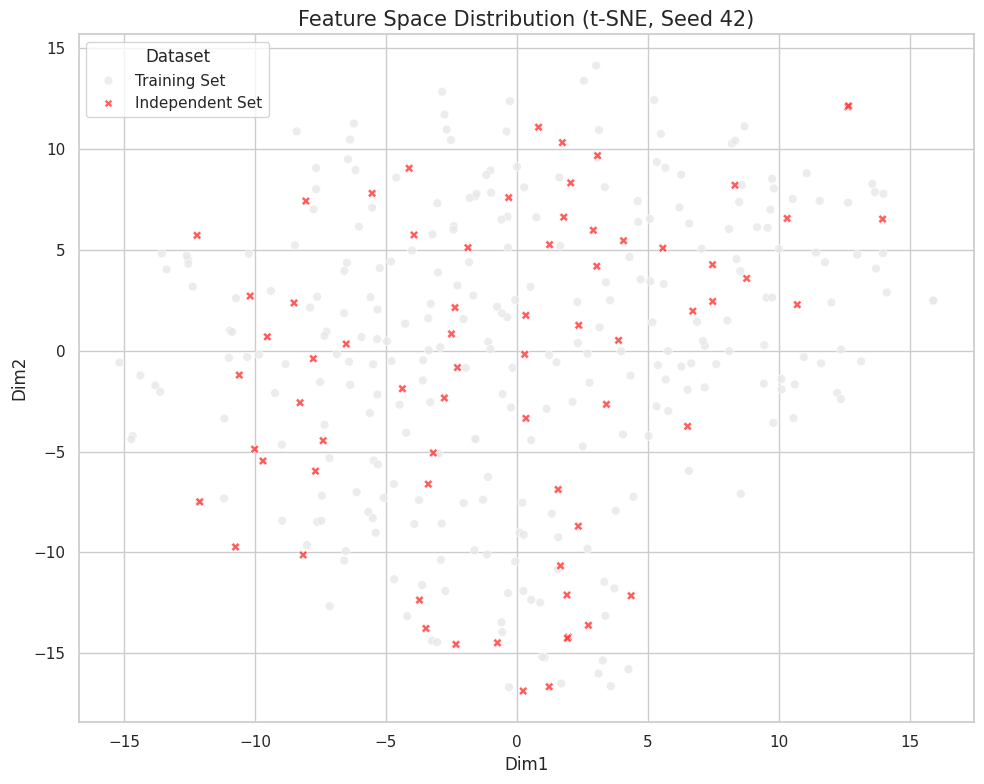

In [18]:
import os
import numpy as np
import pandas as pd
from Bio import SeqIO
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# === 简单的特征提取函数 (为了演示 t-SNE) ===
def get_aac(seq):
    aa_order = 'ACDEFGHIKLMNPQRSTVWY'
    count = {aa: 0 for aa in aa_order}
    for aa in seq:
        if aa in count: count[aa] += 1
    return [count[aa]/len(seq) for aa in aa_order]

def load_data_and_extract_features(fasta_path, label_name):
    recs = list(SeqIO.parse(fasta_path, "fasta"))
    # 提取特征 (这里用 AAC 代替，实际请换成你的 Embedding)
    features = np.array([get_aac(str(r.seq)) for r in recs])
    ids = [r.id for r in recs]
    return features, ids, [label_name] * len(recs)

def main():
    # === 配置 ===
    SEED = 42 
    folder_path = f'split2_seed_{SEED}'
    train_path = os.path.join(folder_path, 'train.fasta')
    test_path = os.path.join(folder_path, 'test.fasta')
    # ===========

    if not os.path.exists(train_path):
        print(f"File not found: {train_path}")
        return

    print("正在加载数据并提取特征...")
    # 1. 准备数据
    X_train, ids_train, y_dataset_train = load_data_and_extract_features(train_path, 'Training Set')
    X_test, ids_test, y_dataset_test = load_data_and_extract_features(test_path, 'Independent Set')

    # 合并数据
    X_combined = np.vstack([X_train, X_test])
    y_dataset = y_dataset_train + y_dataset_test
    
    # 为了防止点太多看不清，可以对训练集进行随机采样 (例如只画 3000 个点)
    if len(X_combined) > 5000:
        print("数据量较大，建议进行下采样以获得更清晰的图...")

    # 2. 运行 t-SNE
    print("正在运行 t-SNE (可能需要几分钟)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_combined)

    # 3. 保存绘图数据
    df_tsne = pd.DataFrame({
        'Dim1': X_embedded[:, 0],
        'Dim2': X_embedded[:, 1],
        'Dataset': y_dataset
    })
    df_tsne.to_csv("Plot_Data_tSNE.csv", index=False)
    print("t-SNE 数据已保存至 Plot_Data_tSNE.csv")

    # 4. 绘图
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df_tsne, x='Dim1', y='Dim2', 
        hue='Dataset', style='Dataset',
        palette={'Training Set': '#E8E8E8', 'Independent Set': '#FF3333'}, # 训练集用浅灰，测试集用亮红
        alpha=0.8, s=40
    )
    

    plt.title(f'Feature Space Distribution (t-SNE, Seed {SEED})', fontsize=15)
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()